<a href="https://colab.research.google.com/github/truonggiaky71-rgb/Nhan_dien_hoa_CNN/blob/main/Nhan_dien_hoa_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import drive
import os
import zipfile


In [58]:
local_zip = '/content/drive/MyDrive/AI/flowers.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_path)
dataset_path = "/content/dataset/flowers"

img_width, img_height = 180, 180
batch_size=128
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 30,
    width_shift_range =0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    dataset_path ,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical"
)


Found 326 images belonging to 5 classes.


In [59]:
num_classes = len(train_generator.class_indices)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
epochs = 30
history = model.fit(
    train_generator,
    epochs=epochs
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2086 - loss: 2.2076
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2853 - loss: 1.6300
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 807ms/step - accuracy: 0.3528 - loss: 1.4434
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 799ms/step - accuracy: 0.4110 - loss: 1.3502
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4693 - loss: 1.2760
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5153 - loss: 1.2046
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.5184 - loss: 1.2038
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 837ms/step - accuracy: 0.5429 - loss: 1.1344
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5767 - loss: 1.0860
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5613 - loss: 1.0675
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6012 - loss: 1.0449
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6043 - loss: 1.0309
Epoch 13/30
3

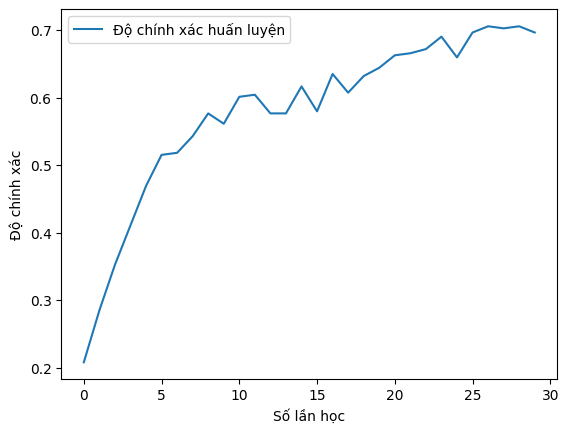

In [61]:
plt.plot(history.history['accuracy'], label="Độ chính xác huấn luyện")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

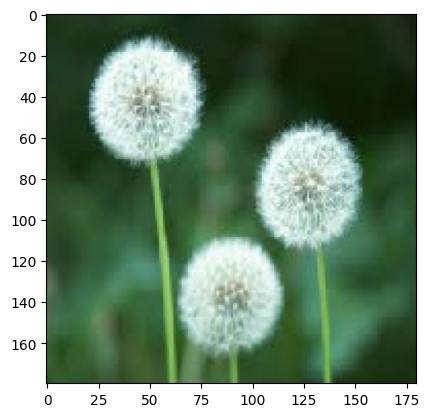

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Loài hoa: dandelion


In [75]:
from keras.utils import load_img
import numpy as np
path ="/content/Flower/Dadelion.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
flower_name = class_labels[prediction]
print(f"Loài hoa: {flower_name}")

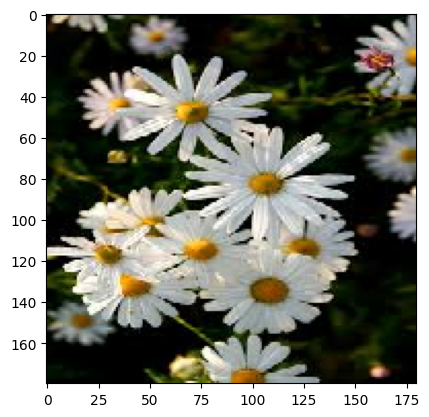

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Loài hoa: daisy


In [76]:
from keras.utils import load_img
import numpy as np
path ="/content/Flower/Daisy.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
flower_name = class_labels[prediction]
print(f"Loài hoa: {flower_name}")

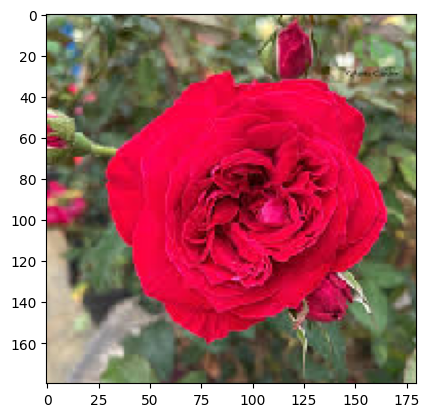

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Loài hoa: rose


In [77]:
from keras.utils import load_img
import numpy as np
path ="/content/Flower/Rose.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
flower_name = class_labels[prediction]
print(f"Loài hoa: {flower_name}")

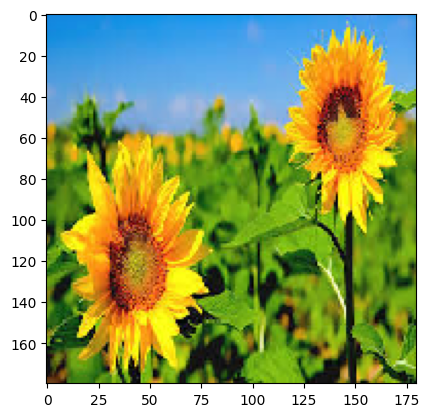

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Loài hoa: sunflower


In [78]:
from keras.utils import load_img
import numpy as np
path ="/content/Flower/Sunflower.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
flower_name = class_labels[prediction]
print(f"Loài hoa: {flower_name}")

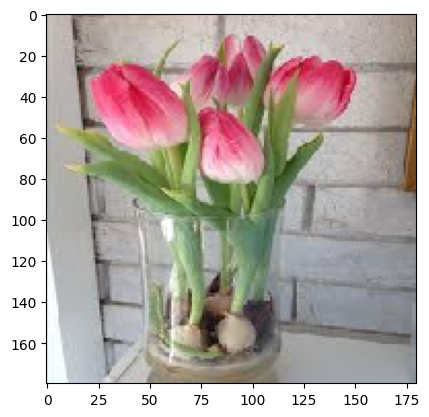

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Loài hoa: tulip


In [79]:
from keras.utils import load_img
import numpy as np
path ="/content/Flower/tulip.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
flower_name = class_labels[prediction]
print(f"Loài hoa: {flower_name}")